In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
#kütüphaneleri yükledik

Matplotlib is building the font cache; this may take a moment.


In [ ]:
raw_data_path= os.path.join("..", "data", "raw", "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

df = pd.read_csv(raw_data_path, encoding='cp1252')

df.head()
#veriyi yükleyip ilk 5 satıra göz attık (2)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
df.columns = df.columns.str.strip()
print(df.columns)

#sütun isimlerindeki boşlukları silip sütun listesini okuduk (3)

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [ ]:
print("Sinif Dagilimi:\n", df['Label'].value_counts())

print("\nVeri Bilgisi:")
df.info()

print("\neksik Değer Sayisi:", df.isnull().sum().sum())

#Veri setindeki sınıf dağılımını bakıp, saısal olmayan (Nan) - sonsuz (ınf9 değeri kontrolü yaptık-4)

Sinif Dagilimi:
 Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

Veri Bilgisi:
<class 'pandas.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             225745 non-null  int64  
 1   Flow Duration                225745 non-null  int64  
 2   Total Fwd Packets            225745 non-null  int64  
 3   Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets  225745 non-null  int64  
 5   Total Length of Bwd Packets  225745 non-null  int64  
 6   Fwd Packet Length Max        225745 non-null  int64  
 7   Fwd Packet Length Min        225745 non-null  int64  
 8   Fwd Packet Length Mean       225745 non-null  float64
 9   Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max        225745 non-null  int64  
 11  Bwd Packet Length Min        2

In [9]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print("temizlik sonrasi eksik deger:", df.isnull().sum().sum())

#burada sonsuz değerlerin hepsini nan yapıp tüm nanları sildik (5)

temizlik sonrasi eksik deger: 0


In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
constant_columns = [col for col in numeric_df.columns if numeric_df[col].std() == 0]
print("elenen Sabit Sutunlar:", constant_columns)
df.drop(columns=constant_columns, inplace=True)

#standart sapması 0 olan sütunları bulup düşürdük(6)

elenen Sabit Sutunlar: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [ ]:
corr_matrix = df.drop('Label', axis=1).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop= [column for column in upper.columns if any(upper[column] > 0.95)]
print("Elenen Yuksek Korelasyonlu Sutunlar:", to_drop)

df.drop(columns=to_drop, inplace=True)
# %95ten fazla korelasyona sahip değerleri modelin kafası karışmasın diye siliyoruz(7)

print(f"Kalan Sutun Sayisi: {len(df.columns)}")(7)

Elenen Yuksek Korelasyonlu Sutunlar: []
Kalan Sutun Sayisi: 43


In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

print(dict(zip(le.classes_, le.transform(le.classes_))))
# Ddosu (saldırı) 1 ve Benign (normal) 0 olarak kodlayıp kontrol ediyoruz (8)

{'BENIGN': np.int64(0), 'DDoS': np.int64(1)}


In [24]:
processed_path = os.path.join("..", "data", "processed", "Friday_Cleaned.csv")
df.to_csv(processed_path, index= False)
print("temizlenmiş veri kaydedildi")

#Temiz verimizi ayrı olarak kaydettik ki temizlik işlemini tekrar tekrar yapmayalım (9)

temizlenmiş veri kaydedildi


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
#kütüphaneleri yükledik
df = pd.read_csv("../data/processed/Friday_Cleaned.csv")

In [4]:
def create_synthetic_log(row):
    # En kritik gördüğümüz 4-5 özelliği seçiyoruz
    log = f"Port_{int(row['Destination Port'])} duration_{int(row['Flow Duration'])} " \
          f"fwd_pkt_{int(row['Total Fwd Packets'])} " \
          f"bytes_s_{float(row['Flow Bytes/s']):.2f}"
    return log


df['synthetic_log'] = df.apply(create_synthetic_log, axis=1)

print("Örnek Yapay Log:", df['synthetic_log'].iloc[0])
#Burada yapay logumuzu oluşturduk (10)

Örnek Yapay Log: Port_54865 duration_3 fwd_pkt_2 bytes_s_4000000.00


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF nesnesini oluşturup max_features ile kelime sayısını sınırlayabiliriz
tfidf = TfidfVectorizer(max_features=50) 

# Logları vektöre çeviriyoruz
tfidf_matrix = tfidf.fit_transform(df['synthetic_log'])

# Vektörleştirilmiş halini bir DataFrame yaptık(11)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

print("NLP Vektör Boyutu:", tfidf_df.shape)

NLP Vektör Boyutu: (225711, 50)


In [6]:
features_df = df.drop(columns=['synthetic_log'])


combined_df = pd.concat([features_df.reset_index(drop=True), 
                         tfidf_df.reset_index(drop=True)], axis=1)

print("Final Veri Seti Boyutu:", combined_df.shape)

#Sayısal özellikler ile NLP vektörlerini yana yana getiriyoruz
#İndekslerin kaymaması için reset_index kullanıyoruz (12)

Final Veri Seti Boyutu: (225711, 93)


In [7]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# X (Özellikler) ve y (Hedef) ayır
X = combined_df.drop(columns=['Label'])
y = combined_df['Label']

# %80 Eğitim, %20 Test olarak verileri ayırdık
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE ile azınlık sınıfı yapay olarak artırıyoruz (13)
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print("SMOTE öncesi eğitim seti dagilimi:", y_train.value_counts().to_dict())
print("SMOTE sonrasi eğitim seti dagilimi:", y_res.value_counts().to_dict())

SMOTE öncesi eğitim seti dagilimi: {1: 102420, 0: 78148}
SMOTE sonrasi eğitim seti dagilimi: {1: 102420, 0: 102420}


In [9]:
from sklearn.model_selection import * # Gerekirse
from sklearn.ensemble import RandomForestClassifier
import time

# Modelin ne kadar sürede eğitildiğini ölçmek SOC mimarisi için önemlidir
start_time = time.time()

# Random Forest modelini tanımlıyoruz
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Modeli dengelenmiş verilerle eğitiyoruz
rf_model.fit(X_res, y_res)

print(f"Random Forest Eğitildi! Süre: {time.time() - start_time:.2f} saniye.")

Random Forest Eğitildi! Süre: 9.26 saniye.


In [10]:
from xgboost import XGBClassifier

start_time = time.time()

# XGBoost modelini tanımlıyoruz
xgb_model = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss')

# Modeli eğitiyoruz
xgb_model.fit(X_res, y_res)

print(f"XGBoost Eğitildi! Süre: {time.time() - start_time:.2f} saniye.")

XGBoost Eğitildi! Süre: 2.76 saniye.


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

def evaluate_soc_model(model, X_test, y_test, model_name):
    # Test seti üzerinde tahminleme yapıyoruz
    predictions = model.predict(X_test)
    
    # Metrikleri hesaplayalım
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions)
    rec = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    
    print(f"=== {model_name} Performans Raporu ===")
    print(f"Doğruluk (Accuracy)     : {acc*100:.2f}%")
    print(f"Kesinlik (Precision)   : {prec*100:.2f}% -> 'Saldırı' dediklerinin kaçı gerçekten saldırı?")
    print(f"Duyarlılık (Recall)     : {rec*100:.2f}% -> Gerçek saldırıların kaçını yakalayabildik?")
    print(f"F1-Skoru (F1-Score)     : {f1*100:.2f}% -> Dengeli başarı metriği")
    print("\nKarmaşıklık Matrisi (Confusion Matrix):")
    print(confusion_matrix(y_test, predictions))
    print("-" * 40)
    
    return predictions

# İki modeli de test edelim
rf_preds = evaluate_soc_model(rf_model, X_test, y_test, "Random Forest")
xgb_preds = evaluate_soc_model(xgb_model, X_test, y_test, "XGBoost")

=== Random Forest Performans Raporu ===
Doğruluk (Accuracy)     : 99.99%
Kesinlik (Precision)   : 99.99% -> 'Saldırı' dediklerinin kaçı gerçekten saldırı?
Duyarlılık (Recall)     : 99.99% -> Gerçek saldırıların kaçını yakalayabildik?
F1-Skoru (F1-Score)     : 99.99% -> Dengeli başarı metriği

Karmaşıklık Matrisi (Confusion Matrix):
[[19536     2]
 [    3 25602]]
----------------------------------------
=== XGBoost Performans Raporu ===
Doğruluk (Accuracy)     : 99.99%
Kesinlik (Precision)   : 99.99% -> 'Saldırı' dediklerinin kaçı gerçekten saldırı?
Duyarlılık (Recall)     : 99.99% -> Gerçek saldırıların kaçını yakalayabildik?
F1-Skoru (F1-Score)     : 99.99% -> Dengeli başarı metriği

Karmaşıklık Matrisi (Confusion Matrix):
[[19536     2]
 [    2 25603]]
----------------------------------------


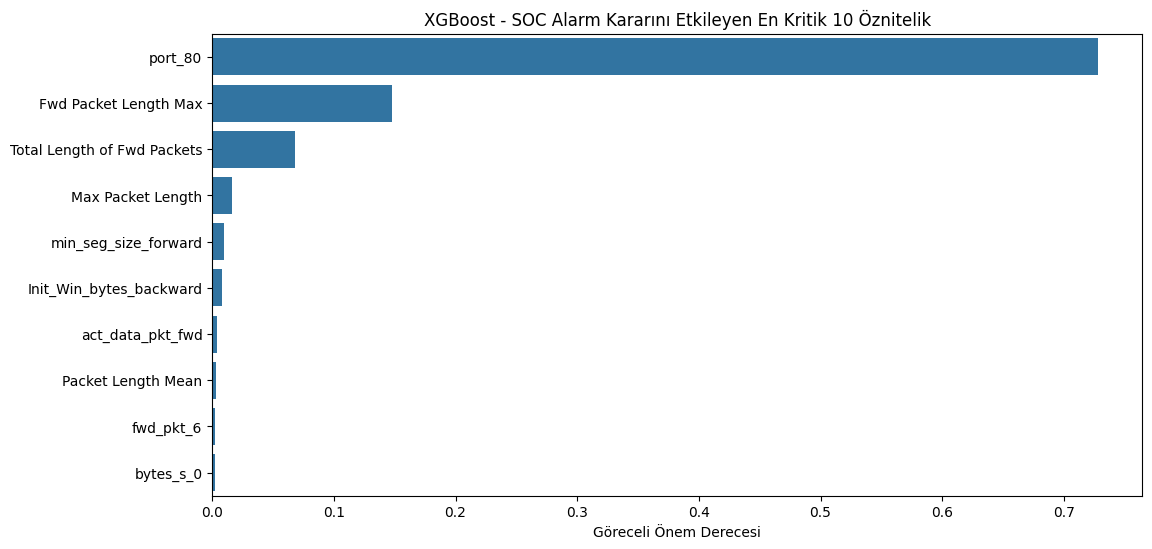

In [12]:
# XGBoost'un en çok önem verdiği ilk 10 özelliği görselleştirelim
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("XGBoost - SOC Alarm Kararını Etkileyen En Kritik 10 Öznitelik")
sns.barplot(x=importances[indices[:10]], y=np.array(X.columns)[indices[:10]])
plt.xlabel("Göreceli Önem Derecesi")
plt.show()